In [841]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

In [842]:
def sigmoid(inpLst):
    return 1/(1+np.exp(-inpLst))
def ReLU(x_):
    return x_ if x_ > 0 else 0
def np_ReLU(x_):
    return np.maximum(0,x_)
def softmax(x_):
    return np.exp(x_ - np.max(x_, keepdims=True)) / np.sum(np.exp(x_ - np.max(x_, keepdims=True)), keepdims=True)
def numerical_gradient(f, x, epsilon=1e-4):
    grad = np.zeros_like(x)
    # 使用 ndenumerate 遍历任意维度的数组，绝对不会越界
    for idx_tuple, _ in np.ndenumerate(x):
        old_val = x[idx_tuple]
        x[idx_tuple] = old_val + epsilon
        loss_plus = f()
        x[idx_tuple] = old_val - epsilon
        loss_minus = f()
        grad[idx_tuple] = (loss_plus - loss_minus) / (2 * epsilon)
        x[idx_tuple] = old_val
    return grad

In [843]:
class neural:#M层N神经元p输入q输出神经网络，中间层维度相同，权重必须为方阵，第一层必须为p*N，最后一层必须为N*q。每一层进行一次向量对权重矩阵的乘法进入下一个向量
    def __init__(self, numMiddle_, inputDim_, middleDim_, outputDim_, matWeight_, vec_b_):
        self.numMid = numMiddle_#中间层数量
        self.inpDim = inputDim_ #输入维度
        self.midDim = middleDim_#隐藏层维度
        self.optDim = outputDim_#输出维度
        self.weight = matWeight_#加载权重(矩阵)
        self.b = vec_b_         #加载偏移(矩阵)
        
    def vowart(self,inp_,h_):
        inp_ = np.atleast_1d(inp_)
        if inp_.shape[0] != self.inpDim:
            raise ValueError(f"输入维度不正确！应为{self.inpDim}, 实际为{inp_.shape[0]}")
        tmp = np.array(inp_).reshape(1, -1)
        match h_.lower():
            case "relu":
                for i in range(self.numMid+1):
                    tmp=np.dot(tmp,self.weight[i])+self.b[i]
                    tmp=np_ReLU(tmp)
            case "sigmoid":
                for i in range(self.numMid+1):
                    tmp=np.dot(tmp,self.weight[i])+self.b[i]
                    tmp=sigmoid(tmp)
            case "softmax":#不要用，不写梯度了
                for i in range(self.numMid+1):
                    tmp=np.dot(tmp,self.weight[i])+self.b[i]
                    tmp=softmax(tmp)
            case _:
                for i in range(self.numMid+1):
                    tmp=np.dot(tmp,self.weight[i])+self.b[i]
        return tmp
    
    def meanSquareError(self, inp_, h_, target_):
        sum_ = 0
    # 将一维输入统一转为二维： (n_samples,) → (n_samples, 1)
        if inp_.ndim == 1:
            inp_ = inp_.reshape(-1, 1)
            target_ = target_.reshape(-1, 1)
        for i in range(inp_.shape[0]):
        # 此时 inp_[i] 形状为 (1,)，正是 vowart 期望的单个样本向量
            sum_ += 0.5 * (self.vowart(inp_[i], h_) - target_[i]) ** 2
        return np.sum(sum_)
    
    def gradient(self, inp_, h_, target_):
        grad_W = []
        grad_b = []
        for i in range(self.numMid + 1):
            f_W = lambda: self.meanSquareError(inp_, h_, target_)
            grad_W.append(numerical_gradient(f_W, self.weight[i]))
            f_b = lambda: self.meanSquareError(inp_, h_, target_)
            grad_b.append(numerical_gradient(f_b, self.b[i]))
        return grad_W, grad_b
    
    def train(self,inp_,h_,target_,alpha_,epsilon_,maxN_):
        for i in range(maxN_):
            if(self.meanSquareError(inp_,h_,target_)<epsilon_):
                break
            grad = self.gradient(inp_,h_,target_)
            for j in range(self.numMid+1):
                self.weight[j]-=alpha_*grad[0][j]
                self.b[j]-=alpha_*grad[1][j]
            if i%100==0:
                print(f"已完成{i/maxN_*100}％")

In [844]:
P=1     #输入维度
M=5     #层数
N=5    #神经元数量
Q=1     #输出维度

Weight=[]
b=[]
for i in range(M+1):
    if i==0:
        Weight.append(np.random.rand(P,N))
        b.append(np.zeros(N))
    elif i == M:
        Weight.append(np.random.rand(N,Q))
        b.append(np.zeros(Q))
    else:
        Weight.append(np.random.rand(N,N))
        b.append(np.zeros(N))

In [845]:
newNeural = neural(M,P,N,Q,Weight,b)
inp=np.array([1.14])
print(newNeural.vowart(inp,"1"))
print(newNeural.vowart(inp,"ReLu"))
print(newNeural.vowart(inp,"sigmOID"))
print(newNeural.vowart(inp,"SOfTMax"))

[[11.86078495]]
[[11.86078495]]
[[0.72409624]]
[[1.]]


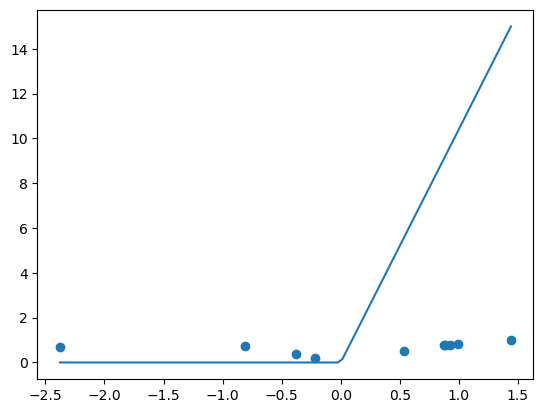

264.83012597814275
已完成0.0％
已完成10.0％
已完成20.0％
已完成30.0％
已完成40.0％
已完成50.0％
已完成60.0％
已完成70.0％
已完成80.0％
已完成90.0％
2.47452702692399


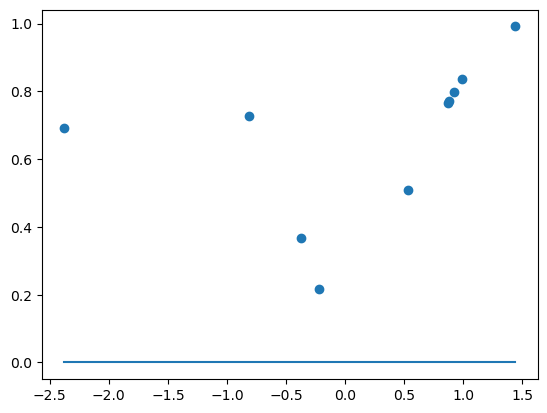

In [846]:
epsilon = 0.01#定义容许误差 Определение допустимой погрешности
maxTime = int(1E3)
alpha = 1E-3

def func(x_):
    return abs(np.sin(x_))

Nn=10
X=np.random.randn(Nn)
Y=func(X)
plotX=np.linspace(min(X),max(X),100)
plotY=[]
plt.scatter(X,Y)
for i in range(len(plotX)):
    plotY.append(newNeural.vowart(plotX[i],"relu").item())
plt.plot(plotX,plotY)
plt.show()
print(newNeural.meanSquareError(X,"relu",Y))
newNeural.train(X,"relu",Y,alpha,epsilon,maxTime)
print(newNeural.meanSquareError(X,"relu",Y))

plt.scatter(X,Y)
plotY=[]
for i in range(len(plotX)):
    plotY.append(newNeural.vowart(plotX[i],"relu").item())
plt.plot(plotX,plotY)
plt.show()